In [3]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from matplotlib.path import Path
import matplotlib.pyplot as plt

from PIL import Image
Image.MAX_IMAGE_PIXELS = None


== SRC mapping ==
 processed image size: 10718 x 9936
 crop size (full-res): 13030 x 13508
 r_x=0.822563, r_y=0.735564, ratio r_x/r_y=1.118275
[WARN] Large difference between r_x and r_y, indicating non-uniform scaling; handled separately.

[OK] Saved to: ./roi_check_outputs/roi_fullres_vertices.csv
[OK] Barcode numbers of 16µm ROI: 5703, saved: ./roi_check_outputs/barcode_16um_in_roi.csv


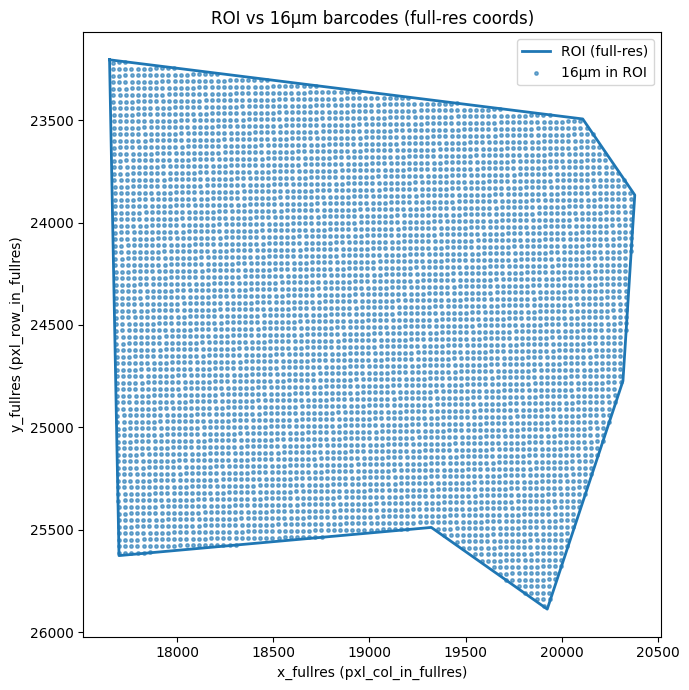

In [4]:
SRC_TISSUE_PARQUET   = "./skin_TXK6Z4X_A1/binned_outputs/square_008um/spatial/tissue_positions.parquet"
SRC_PROCESSED_IMAGE  = "../Example_Data/H1-TXK6Z4X-A1_8um/stardist/he.tiff"

# target: 16µm
TGT_TISSUE_PARQUET   = "./skin_TXK6Z4X_A1/binned_outputs/square_016um/spatial/tissue_positions.parquet"
TGT_PROCESSED_IMAGE  = ""

OUT_DIR = "./roi_check_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

SHOW_PLOT = True

# 2um example ROI
# roi_on_src_processed = [
#     (7558.5, 4332.500000000002),
#     (6862.5, 4332.500000000002),
#     (6774.5, 4812.500000000002),
#     (6822.5, 5660.500000000002),
#     (7310.5, 5940.500000000002),
#     (7598.5, 5900.500000000002),
#     (7958.5, 5964.500000000002),
#     (8174.5, 5836.500000000002),
#     (8278.500000000002, 4780.500000000002),
#     (8302.500000000002, 4452.500000000002),
#     (8142.5, 4132.500000000002),
# ]

# 8um example ROI
roi_on_src_processed = [
    (4489.309866524604, 501.8897103593549),
    (4529.784044314221, 2282.753533102479),
    (5865.431911371565, 2181.5680886284376),
    (6361.240589294366, 2475.005877603157),
    (6685.0340116112975, 1655.403777363424),
    (6735.6267338483185, 987.5798438347524),
    (6513.018756005427, 714.3791437548414)
]


def _ensure_barcode_col(df: pd.DataFrame) -> str:
    candidates = ["barcode", "Barcode", "barcodes", "spot_id", "barcode_id"]
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Could not find barcode column, existing columns: {list(df.columns)[:20]} ...")


def load_crop_bounds_from_tissue_positions(tissue_positions_path: str):
    """Calculate full-res crop bounds (x_min, y_min, x_max, y_max) from tissue_positions.parquet of a dataset."""
    df = pd.read_parquet(tissue_positions_path)
    if "in_tissue" in df.columns:
        df = df.loc[(df["in_tissue"] == 1)].copy()
    else:
        df = df.copy()
    df = df.loc[(df["pxl_row_in_fullres"] >= 0) & (df["pxl_col_in_fullres"] >= 0)]
    df["pxl_row_in_fullres"] = df["pxl_row_in_fullres"].astype(int)
    df["pxl_col_in_fullres"] = df["pxl_col_in_fullres"].astype(int)
    x_min = int(df["pxl_col_in_fullres"].min())
    y_min = int(df["pxl_row_in_fullres"].min())
    x_max = int(df["pxl_col_in_fullres"].max())
    y_max = int(df["pxl_row_in_fullres"].max())
    return (x_min, y_min, x_max, y_max)


def infer_scale_factors(processed_image_path: str, crop_bounds):
    """Infer scale factors r_x, r_y from processed image size and full-res crop bounds."""
    x_min, y_min, x_max, y_max = crop_bounds
    crop_w = x_max - x_min + 1
    crop_h = y_max - y_min + 1
    with Image.open(processed_image_path) as im:
        W_proc, H_proc = im.size  # PIL: (width, height)
    r_x = W_proc / float(crop_w)
    r_y = H_proc / float(crop_h)
    return r_x, r_y, (W_proc, H_proc), (crop_w, crop_h)


def processed_to_fullres(points_proc_xy, crop_bounds, r_x, r_y):
    """Deal with image coordinate system, mapping processed image coords to full-res coords."""
    x_min, y_min, _, _ = crop_bounds
    arr = np.asarray(points_proc_xy, dtype=float)
    xs = arr[:, 0] / r_x + x_min
    ys = arr[:, 1] / r_y + y_min
    return np.column_stack([xs, ys])


def fullres_to_processed(points_full_xy, crop_bounds, r_x, r_y):
    """Full-res coords to processed image coords, reverse mapping for target processed image."""
    x_min, y_min, _, _ = crop_bounds
    arr = np.asarray(points_full_xy, dtype=float)
    us = (arr[:, 0] - x_min) * r_x
    vs = (arr[:, 1] - y_min) * r_y
    return np.column_stack([us, vs])


def barcodes_in_polygon(tissue_positions_path: str, polygon_fullres_xy: np.ndarray):
    """Find barcodes inside the full-res polygon in the target (16µm) tissue_positions."""
    df = pd.read_parquet(tissue_positions_path).copy()
    barcode_col = _ensure_barcode_col(df)
    df = df.loc[(df["pxl_row_in_fullres"] >= 0) & (df["pxl_col_in_fullres"] >= 0)]
    pts = np.column_stack([
        df["pxl_col_in_fullres"].to_numpy(dtype=float),
        df["pxl_row_in_fullres"].to_numpy(dtype=float),
    ])
    poly_path = Path(polygon_fullres_xy)
    inside = poly_path.contains_points(pts)
    out = df.loc[inside, [barcode_col, "pxl_col_in_fullres", "pxl_row_in_fullres"]].copy()
    out = out.rename(columns={
        barcode_col: "barcode",
        "pxl_col_in_fullres": "x_fullres",
        "pxl_row_in_fullres": "y_fullres",
    })
    return out


def quick_summary(tag: str, r_x: float, r_y: float, proc_wh, crop_wh):
    W_proc, H_proc = proc_wh
    crop_w, crop_h = crop_wh
    print(f"== {tag} ==")
    print(f" processed image size: {W_proc} x {H_proc}")
    print(f" crop size (full-res): {crop_w} x {crop_h}")
    print(f" r_x={r_x:.6f}, r_y={r_y:.6f}, ratio r_x/r_y={r_x/r_y:.6f}")
    if abs(r_x - r_y) > 1e-3:
        print("[WARN] Large difference between r_x and r_y, indicating non-uniform scaling; handled separately.")
    print()


def map_polygon_src_to_target(
    src_tissue_parquet: str,
    src_processed_image: str,
    polygon_on_src_processed: list,
    tgt_tissue_parquet: str,
    tgt_processed_image: str = ""
):
    """
    Return:
        roi_fullres_vertices: np.ndarray[N,2]
        bc16_df: DataFrame[barcode, x_fullres, y_fullres]
        roi_on_tgt_processed: np.ndarray[N,2] or None
    """
    # Source: calculate crop bounds and scale factors for source
    crop_src = load_crop_bounds_from_tissue_positions(src_tissue_parquet)
    rxs, rys, src_proc_wh, src_crop_wh = infer_scale_factors(src_processed_image, crop_src)
    quick_summary("SRC mapping", rxs, rys, src_proc_wh, src_crop_wh)

    # Source processed image polygon -> full-res
    roi_fullres = processed_to_fullres(polygon_on_src_processed, crop_src, rxs, rys)

    # Target: find polygon inside 16µm barcodes
    bc16_df = barcodes_in_polygon(tgt_tissue_parquet, roi_fullres)


    roi_on_tgt_proc = None
    if tgt_processed_image and os.path.isfile(tgt_processed_image):
        crop_tgt = load_crop_bounds_from_tissue_positions(tgt_tissue_parquet)
        rxt, ryt, tgt_proc_wh, tgt_crop_wh = infer_scale_factors(tgt_processed_image, crop_tgt)
        quick_summary("TGT mapping", rxt, ryt, tgt_proc_wh, tgt_crop_wh)
        roi_on_tgt_proc = fullres_to_processed(roi_fullres, crop_tgt, rxt, ryt)

    return roi_fullres, bc16_df, roi_on_tgt_proc


# =========================
# Example: 8µm -> 16µm
# =========================
def main():
    roi_fullres, bc16, roi_on_tgt_proc = map_polygon_src_to_target(
        src_tissue_parquet     = SRC_TISSUE_PARQUET,
        src_processed_image    = SRC_PROCESSED_IMAGE,
        polygon_on_src_processed = roi_on_src_processed,
        tgt_tissue_parquet     = TGT_TISSUE_PARQUET,
        tgt_processed_image    = TGT_PROCESSED_IMAGE,
    )

    # Save full-res vertices and 16µm ROI barcodes
    roi_fullres_csv = os.path.join(OUT_DIR, "roi_fullres_vertices.csv")
    pd.DataFrame(roi_fullres, columns=["x_fullres", "y_fullres"]).to_csv(roi_fullres_csv, index=False)
    print(f"[OK] Saved to: {roi_fullres_csv}")

    out16 = os.path.join(OUT_DIR, "barcode_16um_in_roi.csv")
    bc16.to_csv(out16, index=False)
    print(f"[OK] Barcode numbers of 16µm ROI: {len(bc16)}, saved: {out16}")

    if roi_on_tgt_proc is not None:
        roi_tgt_csv = os.path.join(OUT_DIR, "roi_on_16um_processed_vertices.csv")
        pd.DataFrame(roi_on_tgt_proc, columns=["u_16um", "v_16um"]).to_csv(roi_tgt_csv, index=False)
        print(f"[OK] Saved to: {roi_tgt_csv}")

    # Plot
    if SHOW_PLOT:
        plt.figure(figsize=(7, 7))
        poly = np.vstack([roi_fullres, roi_fullres[0]])
        plt.plot(poly[:, 0], poly[:, 1], linewidth=2, label="ROI (full-res)")
        if len(bc16) > 0:
            plt.scatter(bc16["x_fullres"], bc16["y_fullres"], s=6, alpha=0.6, label="16µm in ROI")
        plt.gca().invert_yaxis()
        plt.xlabel("x_fullres (pxl_col_in_fullres)")
        plt.ylabel("y_fullres (pxl_row_in_fullres)")
        plt.title("ROI vs 16µm barcodes (full-res coords)")
        plt.legend()
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()
